In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 📊 Customer Retention & Churn Analysis

### Data Science & Analytics Internship – Task 2

## 🎯 Objective

Analyze customer churn patterns, identify customer retention drivers, and provide data-driven business recommendations to reduce customer churn and improve customer lifetime value.

---

## 🛠️ Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## 📂 Dataset

**Dataset Name:** WA_Fn-UseC_-Telco-Customer-Churn.csv

**Source:** Telco Customer Churn Dataset (Kaggle)

This dataset contains customer demographic information, subscription details, billing information, tenure, and churn status. It is used to identify customer churn patterns, analyze retention trends, and generate actionable business insights.

# 📥 Data Loading

### Loading the Dataset

The customer churn dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [23]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.shape

(7043, 21)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 🧹 Data Cleaning & Preprocessing

### Data Cleaning

The dataset is cleaned by:

- Converting **TotalCharges** to numeric format.
- Checking for missing values.
- Removing incomplete records.
- Preparing the dataset for customer churn analysis.

In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [28]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [29]:
df.dropna(inplace=True)

In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

This section explores customer churn patterns, customer behavior, and key factors affecting customer retention using data visualizations and business insights.

In [31]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [32]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

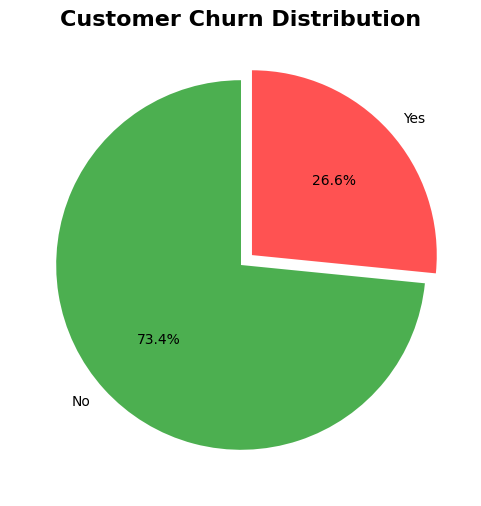

In [33]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#FF5252"],
    explode=(0, 0.08)
)

plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold")
plt.ylabel("")
plt.show()

## 📈 Business Insight 1

### Observation

- Total Customers: **7032**
- Retained Customers: **5163 (73.4%)**
- Churned Customers: **1869 (26.6%)**

### Recommendation

Approximately one out of every four customers has churned. The company should improve customer engagement, strengthen loyalty programs, and proactively identify customers who are at risk of leaving.

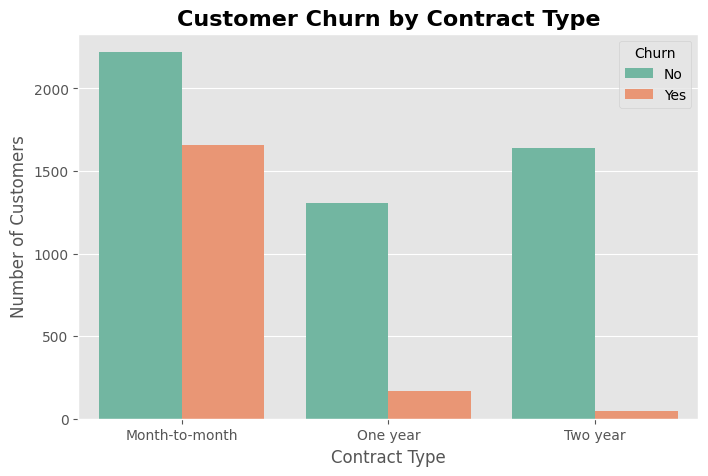

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Contract Type", fontsize=16, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight 2

### Observation

Customers with **Month-to-Month** contracts show the highest churn compared to customers with **One-Year** and **Two-Year** contracts.

### Recommendation

The company should encourage customers to switch to long-term contracts by offering discounts, loyalty rewards, or exclusive benefits to improve customer retention.

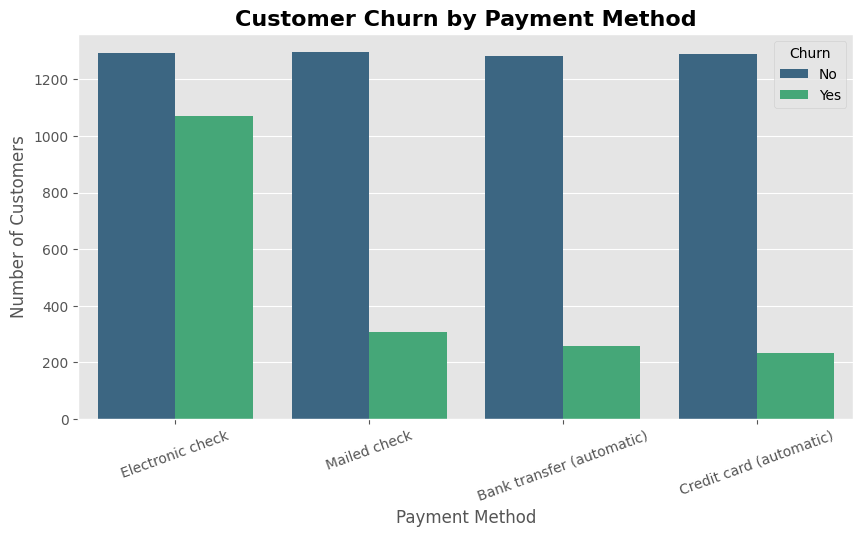

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="viridis"
)

plt.title("Customer Churn by Payment Method", fontsize=16, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

## 📈 Business Insight 3

### Observation

Customers using **Electronic Check** as their payment method have the highest churn rate compared to other payment methods.

### Recommendation

The company should encourage customers to use more reliable payment methods such as automatic bank transfers or credit card payments by offering incentives and improving the payment experience.

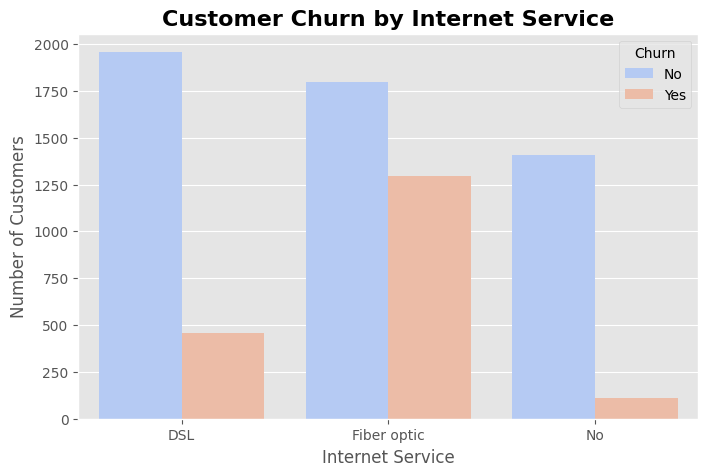

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="coolwarm"
)

plt.title("Customer Churn by Internet Service", fontsize=16, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight 4

### Observation

Customers using **Fiber Optic** internet service show a higher churn rate compared to DSL and customers with no internet service.

### Recommendation

The company should improve the quality of Fiber Optic services, provide better customer support, and introduce attractive pricing plans to reduce churn.

C:\Users\admin\AppData\Local\Temp\ipykernel_20572\2438177257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


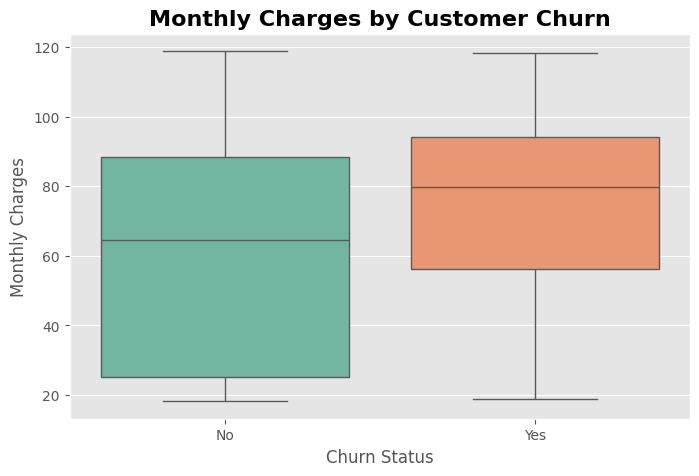

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges by Customer Churn", fontsize=16, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

## 📈 Business Insight 5

### Observation

Customers with higher monthly charges are more likely to churn than customers with lower monthly charges.

### Recommendation

The company should introduce flexible pricing plans, discounts, or value-added services for customers with high monthly charges to improve customer retention.

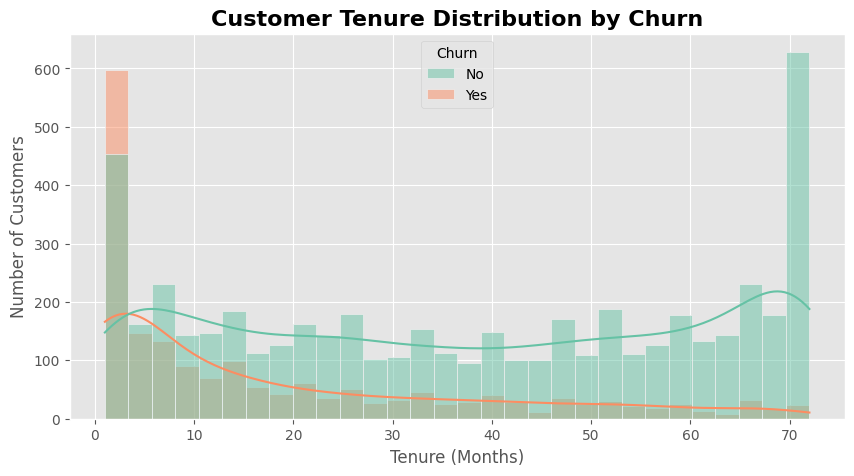

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    palette="Set2"
)

plt.title("Customer Tenure Distribution by Churn", fontsize=16, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight 6

### Observation

Customers with shorter tenure (especially within the first 12 months) have a higher probability of churning compared to long-term customers.

### Recommendation

The company should strengthen customer onboarding, provide welcome offers, and engage new customers during their first year to improve retention.

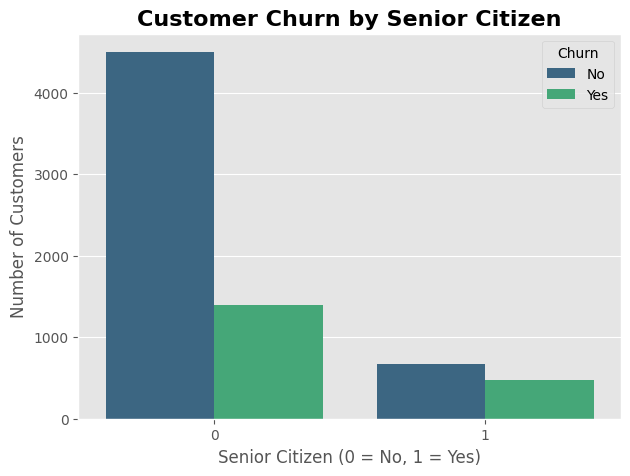

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="viridis"
)

plt.title("Customer Churn by Senior Citizen", fontsize=16, fontweight="bold")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight 7

### Observation

Senior citizens have a relatively higher churn rate compared to non-senior customers.

### Recommendation

The company should provide personalized customer support, senior-friendly service plans, and loyalty benefits to improve retention among senior customers.

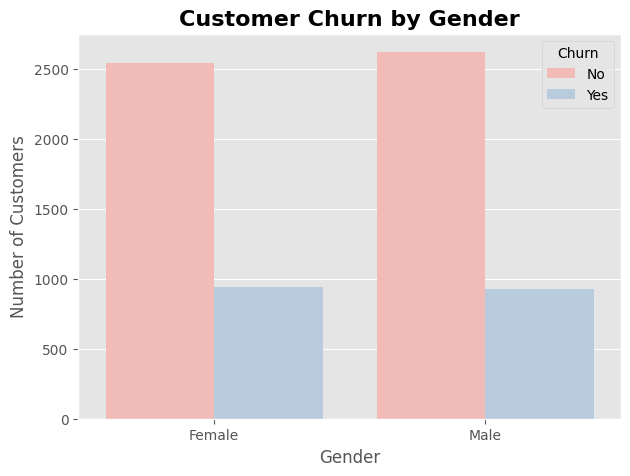

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Pastel1"
)

plt.title("Customer Churn by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 📈 Business Insight 8

### Observation

The churn rate is almost similar for both male and female customers, indicating that gender has little influence on customer churn.

### Recommendation

Retention strategies should focus more on customer behavior, contract type, service quality, and pricing rather than gender.

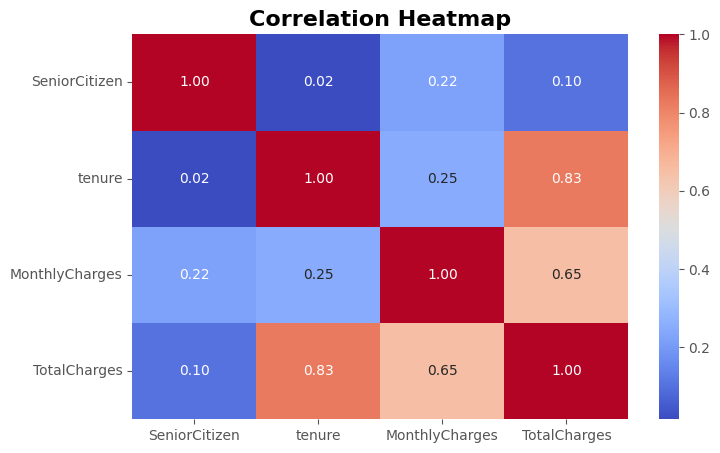

In [42]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

## 📈 Business Insight 9

### Observation

The heatmap shows that **Monthly Charges** and **Tenure** have the strongest relationships with customer behavior, while **Senior Citizen** has only a weak correlation with other numerical features.

### Recommendation

The business should prioritize improving pricing strategies and customer retention initiatives based on customer tenure, as these factors have a greater impact on churn.

# 🎯 Final Business Recommendations

Based on the analysis, the following actions are recommended to reduce customer churn:

1. Encourage customers to move from Month-to-Month contracts to One-Year or Two-Year plans by offering discounts and loyalty rewards.

2. Improve Fiber Optic service quality and strengthen customer support to reduce dissatisfaction.

3. Offer personalized retention campaigns for customers with high monthly charges.

4. Focus on retaining new customers during their first 12 months through onboarding programs and engagement campaigns.

5. Promote secure automatic payment methods instead of Electronic Check by providing incentives.

6. Develop targeted retention strategies for senior citizens by offering customized support and special service plans.

7. Use customer behavior analytics to identify high-risk customers and take proactive retention actions before they leave.

# ✅ Conclusion

This project analyzed customer churn using the Telco Customer Churn dataset.

The analysis identified several key factors influencing customer churn, including contract type, payment method, internet service, monthly charges, and customer tenure.

The insights and recommendations generated from this analysis can help businesses improve customer retention, reduce churn, and increase long-term customer value through data-driven decision making.